In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 5*x**2-9*x+20

In [3]:
f(2.0)

22.0

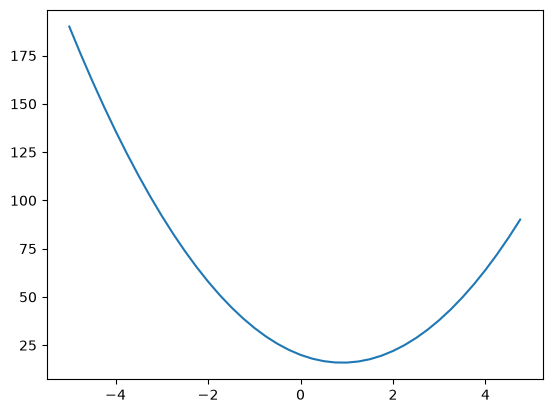

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

How to get f(x)'s derivative?
1. By formula, yet explict function is needed. 
2. By definition, we change a little on x, to see how much the f(x) changes. 

In [5]:
h = 0.00001 # a small positive step
x = -3.0
(f(x+h)-f(x))/h

-38.99995000153922

In [6]:
# more complex: multiple input values
a = 2.0
b = -3.0
c = 10.0
d = a*b + c # d=f(a,b,c)=a*b+c
d

4.0

In [7]:
h = 0.000001

a = 2.0
b = -3.0
c = 10.0
d1 = a*b + c
c += h
d2 = a*b + c

(d2-d1)/h # partial derivative of d respect to a

0.9999999992515995

In [47]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        # printable representation (differ from 'readable' format)
        return f'Value(data={self.data})'

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

a = Value(2.0, label='a')
b = Value(4.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label='e'
d = e + c; d.label='d'; d.grad = -1.0
f = Value(-1.0, label='f');f.grad=18.0
L = d * f; L.label='L';L.grad=1.0
L

Value(data=-18.0)

In [44]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label='{ %s | data %.4f | grad %.4f }' % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid+n._op, label=n._op)
            dot.edge(uid+n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+n2._op)
    return dot


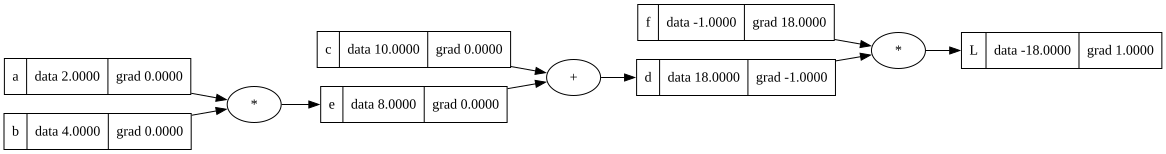

In [48]:
draw_dot(L)

In [ ]:
def lol():
    h = 0.00001

    a = Value(2.0, label='a')
    b = Value(4.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e + c; d.label='d'
    f = Value(-1.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data


    a = Value(2.0, label='a')
    b = Value(4.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e + c; d.label='d'
    f = Value(-1.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data + h
    print((L2-L1)/h)
lol()

0.9999999999621422
